# Identifying Player Engagement Through Regression Models
## Steam Games Dataset — Comparative Analysis

This notebook presents a unified analysis of three machine learning approaches applied to the Steam games dataset,
all aiming to understand what drives player engagement as measured by **average playtime forever**.

### Models Covered
| Notebook | Task Type | Models |
|---|---|---|
| **Linear Regression** | Regression (continuous target) | Linear, Ridge (L2), Lasso (L1) |
| **Logistic Regression + SVM** | Classification (binary target) | Logistic Regression (L1/L2), LinearSVC (L1/L2) |
| **Logistic Regression + SMOTE** | Classification with class balancing | Logistic Regression (L1/L2) with SMOTE oversampling |

### Why Three Different Approaches?
All three notebooks share the same dataset and target variable (`average_playtime_forever`), but frame
the problem differently:
- **Regression** treats playtime as a continuous variable and asks *how much* will a player engage.
- **Classification** (SVM/Logistic) binarizes playtime at the median and asks *will a player engage highly or not*.
- **Classification + SMOTE** addresses the class imbalance that arises from that binarization.

These different framings, and the preprocessing choices that follow from them, explain the striking
differences in reported performance metrics across notebooks.

---

*By Robert Bamba and Shifra Abigail Garcia*

## I. Importing the Required Libraries

The following libraries are used for data handling, visualization, preprocessing, and modeling
across all three approaches. We import everything up front so the rest of the notebook runs
without interruption.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import ast
import mglearn            # visualization helpers (amueller)
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# SMOTE for class imbalance
try:
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn loaded successfully.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn installed and loaded.")

pd.options.display.float_format = '{:,.2g}'.format
print("All libraries imported successfully.")

imbalanced-learn loaded successfully.
All libraries imported successfully.


## II. Loading the Dataset

The dataset is loaded into a pandas DataFrame so that its structure and contents can be examined.
All three models work from the same raw source file.

In [2]:
df = pd.read_csv('games_steam.csv')
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (94954, 44)

First few rows:


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,7.3e+02,Counter-Strike 2,8/21/2012,0,0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,5.8e+05,PUBG: BATTLEGROUNDS,12/21/2017,0,0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,5.7e+02,Dota 2,7/9/2013,0,0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,2.7e+05,Grand Theft Auto V Legacy,4/13/2015,17,0,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,4.9e+05,Tom Clancy's Rainbow Six® Siege,12/1/2015,17,20,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [3]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'achievements', 'recommendations', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent']


In [4]:
print("Data Types:")
df.dtypes

Data Types:


appid                       float64
name                            str
release_date                    str
required_age                float64
price                       float64
dlc_count                   float64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                      object
mac                          object
linux                        object
metacritic_score             object
achievements                 object
recommendations              object
supported_languages             str
full_audio_languages            str
packages                        str
developers                      str
publishers                      str
categories                      str
genres                          str
screenshots                 

## III. Checking Missing Values

Before training any model, the dataset must be checked for missing values.
Missing values affect both training stability and the validity of learned relationships.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
})

print("Columns with missing values:")
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

Columns with missing values:


,Missing Count,Percentage (%)
reviews,84523,89
full_audio_languages,55093,58
website,53762,57
support_url,50771,53
tags,22121,23
packages,19079,20
support_email,16105,17
movies,7669,8.1
categories,5911,6.2
publishers,5784,6.1


## IV. Data Cleaning

The dataset is cleaned to make it suitable for all modeling approaches.

The following cleaning steps are performed:
- Removing unnamed index columns introduced by CSV export
- Trimming extra whitespace from column names and string values
- Dropping columns with more than 20,000 missing values (too sparse to be useful)
- Dropping irrelevant metadata columns (screenshots, URLs, descriptions, etc.)
- Filling remaining numeric nulls with the column median
- Dropping any rows that still contain nulls after imputation

In [6]:
# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Create a working copy
df_clean = df.copy()

# Strip extra whitespace from column names
df_clean.columns = df_clean.columns.str.strip()

# Drop columns with too many missing values (> 20,000 NaNs)
threshold = 20000
df_clean = df_clean.loc[:, df_clean.isna().sum() <= threshold]

# Drop irrelevant columns
cols_to_drop = [
    "appid", "screenshots", "about_the_game", "short_description",
    "website", "support_url", "support_email", "movies", "header_image",
    "release_date", "detailed_description", "packages",
    "average_playtime_2weeks", "median_playtime_forever",
    "median_playtime_2weeks", "positive", "negative",
    "pct_pos_total", "pct_pos_recent", "num_reviews_total",
    "num_reviews_recent", "peak_ccu", "recommendations",
]
df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

# Clean helper: strip dirty patterns and coerce to numeric
def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype(str)
        .str.strip()
        .str.replace(r"^id_", "", regex=True)
        .str.replace(r"_x$", "", regex=True)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan),
        errors="coerce"
    )

# Impute numeric nulls with column medians
numeric_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print("Shape after initial cleaning:", df_clean.shape)
print("\nRemaining missing values (top 10):")
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))

Shape after initial cleaning: (94954, 18)

Remaining missing values (top 10):
categories             5911
publishers             5784
developers             5455
genres                 5445
supported_languages    5416
name                     13
windows                   7
achievements              6
linux                     6
mac                       6
dtype: int64


In [7]:
# Drop rows with any remaining nulls
df_clean = df_clean.dropna()
print("Final cleaned shape:", df_clean.shape)
print("\nColumns remaining:")
print(df_clean.columns.tolist())

Final cleaned shape: (88131, 18)

Columns remaining:
['name', 'required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux', 'metacritic_score', 'achievements', 'supported_languages', 'developers', 'publishers', 'categories', 'genres', 'user_score', 'estimated_owners', 'average_playtime_forever', 'discount']


## V. Conversion

After cleaning, several columns require type conversion before modeling:

- **Boolean columns** (`windows`, `mac`, `linux`) are converted from string `"True"/"False"` to integers `1/0`.
- **List-like columns** (stored as string representations of Python lists) are parsed back into actual Python lists
  using `ast.literal_eval`. This is needed before multi-label encoding.
- **Multi-label features** (`supported_languages`, `developers`, `publishers`, `categories`, `genres`)
  are binary-encoded using `MultiLabelBinarizer`. For developers and publishers, only the top 100
  most common values are retained to keep dimensionality manageable.

In [8]:
# Convert boolean platform columns to 0/1
bool_cols = ["windows", "mac", "linux"]
df_clean[bool_cols] = df_clean[bool_cols].apply(
    lambda col: col.astype(str).str.strip().str.upper().map({"TRUE": 1, "FALSE": 0})
)

# Parse stringified list columns back to Python lists
list_cols = ["supported_languages", "developers", "publishers", "categories", "genres"]
for col in list_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

print("Data types after conversion:")
print(df_clean.dtypes)

Data types after conversion:
name                            str
required_age                float64
price                       float64
dlc_count                   float64
windows                       int64
mac                           int64
linux                         int64
metacritic_score             object
achievements                 object
supported_languages          object
developers                   object
publishers                   object
categories                   object
genres                       object
user_score                   object
estimated_owners                str
average_playtime_forever     object
discount                     object
dtype: object


In [9]:
# Encode supported_languages
mlb = MultiLabelBinarizer()
lang_encoded = mlb.fit_transform(df_clean["supported_languages"])
lang_df = pd.DataFrame(lang_encoded, columns=[f"lang_{c}" for c in mlb.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, lang_df], axis=1)
print(f"Languages encoded: {lang_df.shape[1]} features")

Languages encoded: 107 features


In [10]:
# Encode top 100 developers
top_devs = df_clean["developers"].explode().value_counts().head(100).index
df_clean["developers_filtered"] = df_clean["developers"].apply(lambda x: [i for i in x if i in top_devs])
mlb = MultiLabelBinarizer()
dev_encoded = mlb.fit_transform(df_clean["developers_filtered"])
dev_df = pd.DataFrame(dev_encoded, columns=[f"dev_{c}" for c in mlb.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, dev_df], axis=1)
print(f"Top 100 developers encoded: {dev_df.shape[1]} features")

Top 100 developers encoded: 100 features


In [11]:
# Encode top 100 publishers
top_pub = df_clean["publishers"].explode().value_counts().head(100).index
df_clean["publishers_filtered"] = df_clean["publishers"].apply(lambda x: [i for i in x if i in top_pub])
mlb_pub = MultiLabelBinarizer()
pub_encoded = mlb_pub.fit_transform(df_clean["publishers_filtered"])
pub_df = pd.DataFrame(pub_encoded, columns=[f"pub_{c}" for c in mlb_pub.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, pub_df], axis=1)
print(f"Top 100 publishers encoded: {pub_df.shape[1]} features")

Top 100 publishers encoded: 100 features


In [12]:
# Encode categories
mlb_cat = MultiLabelBinarizer()
cat_encoded = mlb_cat.fit_transform(df_clean["categories"])
cat_df = pd.DataFrame(cat_encoded, columns=[f"cat_{c}" for c in mlb_cat.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, cat_df], axis=1)
print(f"Categories encoded: {cat_df.shape[1]} features")

Categories encoded: 40 features


In [13]:
# Encode genres
mlb_gen = MultiLabelBinarizer()
gen_encoded = mlb_gen.fit_transform(df_clean["genres"])
gen_df = pd.DataFrame(gen_encoded, columns=[f"genre_{c}" for c in mlb_gen.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, gen_df], axis=1)
print(f"Genres encoded: {gen_df.shape[1]} features")
print(f"\nDataset shape after all encoding: {df_clean.shape}")

Genres encoded: 33 features

Dataset shape after all encoding: (88131, 400)


In [14]:
# Drop original multi-label columns — no longer needed
df_clean = df_clean.drop(columns=[
    "supported_languages", "developers", "publishers", "categories", "genres",
    "developers_filtered", "publishers_filtered"
])

print(f"Final cleaned dataset shape: {df_clean.shape}")
print("\nDataset overview:")
df_clean.head()

Final cleaned dataset shape: (88131, 393)

Dataset overview:


,name,required_age,price,dlc_count,windows,mac,linux,metacritic_score,achievements,user_score,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,Counter-Strike 2,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,PUBG: BATTLEGROUNDS,0,0,0,1,0,0,0,37,0,...,0,0,0,0,0,0,0,0,0,0
2,Dota 2,0,0,2,1,1,1,90,0,0,...,0,0,0,0,1,0,0,0,0,0
3,Grand Theft Auto V Legacy,17,0,0,1,0,0,96,77,0,...,0,0,0,0,0,0,0,0,0,0
4,Tom Clancy's Rainbow Six® Siege,17,20,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## VI. Correlation

Correlation analysis is performed to:
1. Visualize the overall structure of relationships among numeric features.
2. Identify pairs of features with correlation > 0.9 — a sign of multicollinearity that can destabilize linear models.

Note that the Linear Regression notebook takes the additional step of *dropping* highly correlated columns
from `df_model` before training, while the classification notebooks retain them but rely on regularization
(L1/L2 penalties) to handle multicollinearity implicitly.

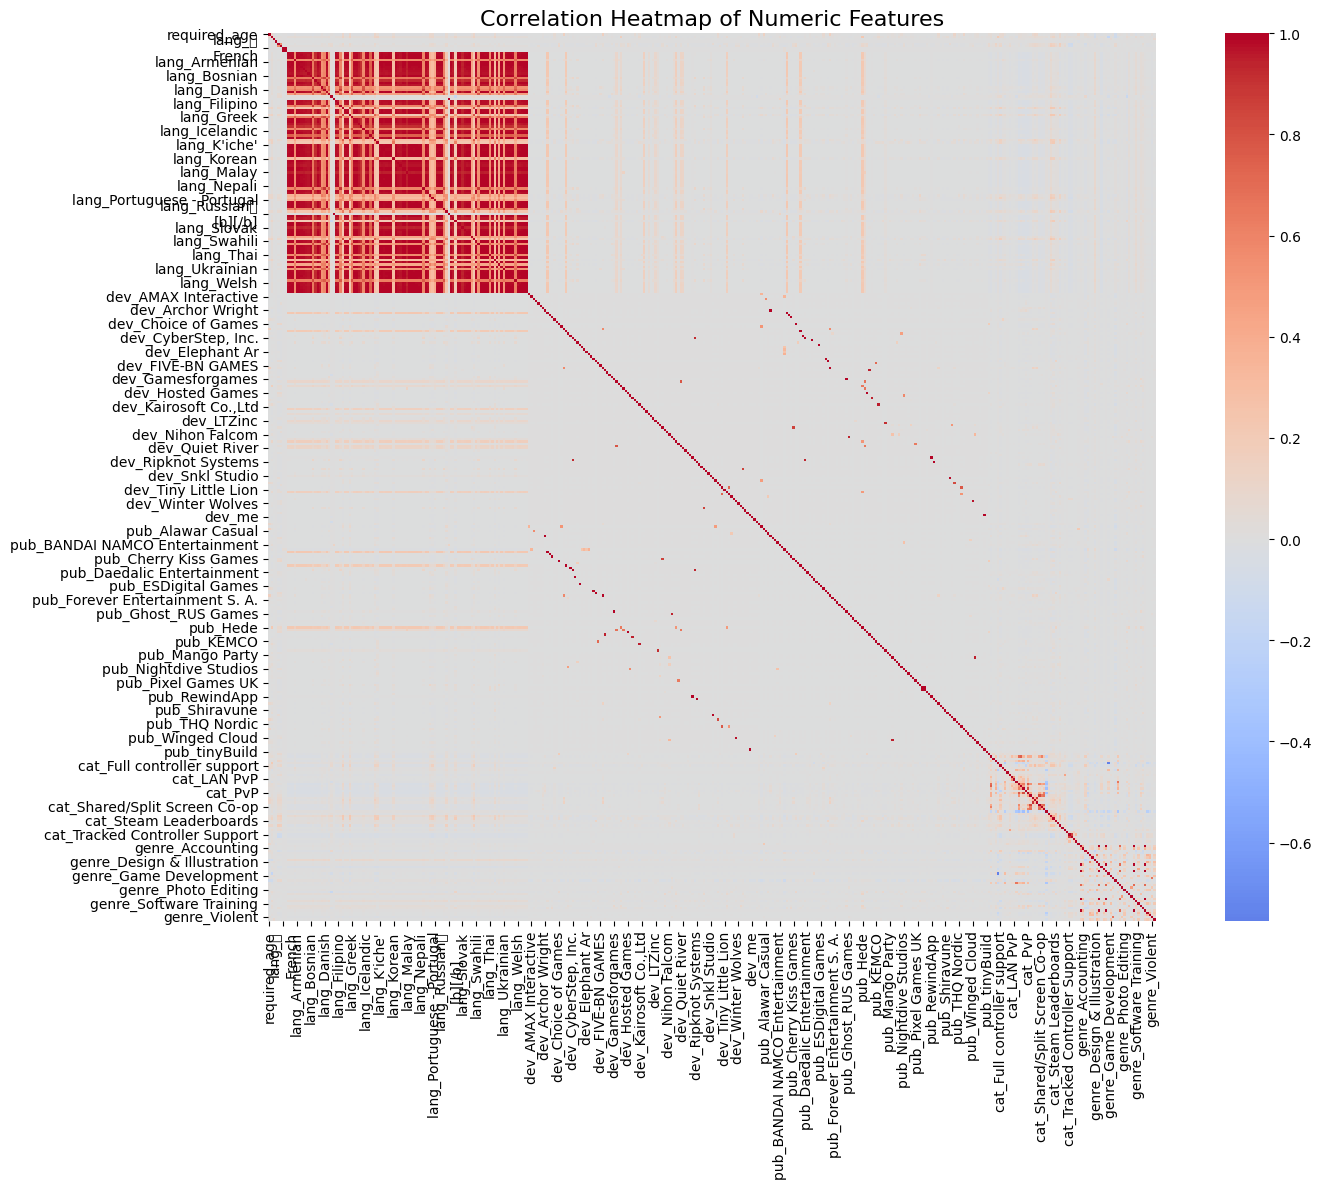

Number of numeric features: 386


In [15]:
plt.figure(figsize=(16, 12))
numeric_df = df_clean.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Number of numeric features: {numeric_df.shape[1]}")

In [16]:
# Find strongly correlated feature pairs (threshold = 0.9)
corr_matrix = numeric_df.corr()
threshold = 0.9

print(f"Feature pairs with |correlation| > {threshold}:\n")

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_pairs.append((col1, col2, corr_value))
            print(f"{col1:30s} <--> {col2:30s} : {corr_value:.3f}")

if len(corr_pairs) == 0:
    print("No feature pairs with |correlation| > 0.9 found.")
else:
    print(f"\nTotal highly correlated pairs found: {len(corr_pairs)}")

Feature pairs with |correlation| > 0.9:

lang_
French                  <--> lang_
German                  : 1.000
lang_Afrikaans                 <--> lang_Albanian                  : 0.982
lang_Afrikaans                 <--> lang_Amharic                   : 0.981
lang_Afrikaans                 <--> lang_Armenian                  : 0.984
lang_Afrikaans                 <--> lang_Assamese                  : 0.981
lang_Afrikaans                 <--> lang_Azerbaijani               : 0.979
lang_Afrikaans                 <--> lang_Bangla                    : 0.970
lang_Afrikaans                 <--> lang_Basque                    : 0.971
lang_Afrikaans                 <--> lang_Belarusian                : 0.967
lang_Afrikaans                 <--> lang_Bosnian                   : 0.977
lang_Afrikaans                 <--> lang_Catalan                   : 0.928
lang_Afrikaans                 <--> lang_Cherokee                  : 0.977
lang_Afrikaans                 <--> lang_Croatian            

## VII. Normalization and Identifying the Target

This section diverges across the three modeling approaches, reflecting a fundamental design decision:
**how to treat `average_playtime_forever`**.

| Approach | Target Treatment | Normalization |
|---|---|---|
| **Linear Regression** | Continuous — log-transformed (`log1p`), then Min-Max scaled | Full dataset normalized as matrix |
| **Logistic Regression / SVM** | Binary — 1 if above-median playtime, 0 otherwise | Features only (Min-Max), target stays 0/1 |
| **Logistic Regression + SMOTE** | Same binary target, but class imbalance is then addressed | Features only (Min-Max), SMOTE applied after split |

> This divergence in target encoding is the **primary reason** the reported metrics look so different:
> regression reports R² (~0.26–0.34), while classification reports accuracy (~60–70%).
> They are measuring entirely different things on different formulations of the same problem.

### 7.1 — For Linear Regression (continuous target)

In [17]:
# ── LINEAR REGRESSION SETUP ──────────────────────────────────────────────
df_model_lin = df_clean.copy()

target_col = "average_playtime_forever"

# Ensure numeric
df_model_lin[target_col] = pd.to_numeric(df_model_lin[target_col], errors='coerce')
df_model_lin = df_model_lin.dropna(subset=[target_col])

# Remove zero-playtime rows — they are noise rather than signal
df_model_lin = df_model_lin[df_model_lin[target_col] > 0]

# Log-transform the target to reduce right-skew
df_model_lin[target_col] = np.log1p(df_model_lin[target_col])

# Keep numeric columns only
df_model_lin = df_model_lin.select_dtypes(include=['number']).dropna()

# Drop highly correlated features (retain target column regardless)
corr_mat = df_model_lin.corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

to_drop = [
    col for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.9 and col != target_col and row != target_col
]

df_model_lin = df_model_lin.drop(columns=set(to_drop))
print(f"Dropped {len(set(to_drop))} highly correlated columns.")
print("Shape after correlation-based feature reduction:", df_model_lin.shape)

Dropped 84 highly correlated columns.
Shape after correlation-based feature reduction: (7915, 303)


In [18]:
# Min-Max normalize the full dataset (features + target together, as in Linear_Regression.ipynb)
mms = MinMaxScaler()
X_norm_arr = mms.fit_transform(np.array(df_model_lin))
df_norm = pd.DataFrame(X_norm_arr, columns=df_model_lin.columns)

X_lin = df_norm.drop(columns=[target_col])
y_lin = df_norm[target_col]

print(f"Features (X_lin): {X_lin.shape}")
print(f"Target  (y_lin): {y_lin.shape}")

Features (X_lin): (7915, 302)
Target  (y_lin): (7915,)


### 7.2 — For Classification (binary target, used by both Logistic/SVM and SMOTE notebooks)

In [19]:
# ── CLASSIFICATION SETUP ─────────────────────────────────────────────────
df_model_cls = df_clean.copy()

target_col = "average_playtime_forever"
df_model_cls[target_col] = pd.to_numeric(df_model_cls[target_col], errors='coerce')
df_model_cls = df_model_cls.dropna(subset=[target_col])

# Binarize at median: 1 = popular (above median), 0 = not popular
median_playtime = df_model_cls[target_col].median()
df_model_cls['is_popular'] = (df_model_cls[target_col] > median_playtime).astype(int)

print(f"Median playtime threshold: {median_playtime:.2f} minutes")
print("\nTarget variable distribution:")
print(df_model_cls['is_popular'].value_counts())
print("\nClass proportions:")
print(df_model_cls['is_popular'].value_counts(normalize=True))

imbalance_ratio = df_model_cls['is_popular'].value_counts().max() / df_model_cls['is_popular'].value_counts().min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

Median playtime threshold: 0.00 minutes

Target variable distribution:
is_popular
0    80216
1     7915
Name: count, dtype: int64

Class proportions:
is_popular
0   0.91
1   0.09
Name: proportion, dtype: float64

Imbalance ratio: 10.13:1


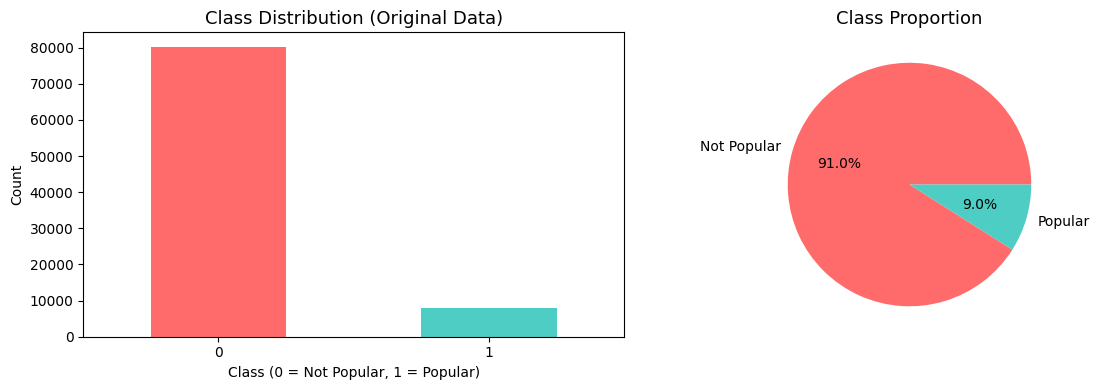

In [20]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_model_cls['is_popular'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Class Distribution (Original Data)', fontsize=13)
axes[0].set_xlabel('Class (0 = Not Popular, 1 = Popular)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_model_cls['is_popular'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#FF6B6B', '#4ECDC4'], labels=['Not Popular', 'Popular']
)
axes[1].set_title('Class Proportion', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [21]:
# Select numeric features; drop original playtime column
df_model_cls = df_model_cls.select_dtypes(include=['number'])
df_model_cls = df_model_cls.drop(columns=['average_playtime_forever'], errors='ignore')
df_model_cls = df_model_cls.dropna()

X_cls = df_model_cls.drop(columns=['is_popular'])
y_cls = df_model_cls['is_popular']

# Normalize features with Min-Max (target stays as 0/1)
scaler = MinMaxScaler()
X_cls_norm = pd.DataFrame(scaler.fit_transform(X_cls), columns=X_cls.columns)

print(f"Features (X_cls_norm): {X_cls_norm.shape}")
print(f"Target  (y_cls): {y_cls.shape}")

# Train-test split (stratified to preserve class balance)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_norm, y_cls, test_size=0.25, stratify=y_cls, random_state=42
)
print(f"\nTrain size: {X_train_cls.shape[0]}  |  Test size: {X_test_cls.shape[0]}")

Features (X_cls_norm): (88131, 386)
Target  (y_cls): (88131,)

Train size: 66098  |  Test size: 22033


In [22]:
# Apply SMOTE to training data (used only in the SMOTE approach)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_cls, y_train_cls)

print("=== BEFORE SMOTE ===")
print(Counter(y_train_cls))
print("\n=== AFTER SMOTE ===")
print(Counter(y_train_smote))
print(f"\nSynthetic samples created: {len(X_train_smote) - len(X_train_cls)}")

=== BEFORE SMOTE ===
Counter({0: 60162, 1: 5936})

=== AFTER SMOTE ===
Counter({0: 60162, 1: 60162})

Synthetic samples created: 54226


---
## VIII. Linear Regression

Linear Regression is used as the baseline model to understand the relationship between
the predictor variables and the continuous (log-transformed) target `average_playtime_forever`.

The model is trained 100 times across different random states to ensure results are stable
and not dependent on a single data split. Average training and testing R² scores are reported.

In [23]:
training_accuracy_lin = []
test_accuracy_lin = []
coeff_lin = []

for rs in range(0, 100):
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lin, y_lin, random_state=rs)
    model_lin = LinearRegression()
    model_lin.fit(X_train_l, y_train_l)
    training_accuracy_lin.append(model_lin.score(X_train_l, y_train_l))
    test_accuracy_lin.append(model_lin.score(X_test_l, y_test_l))
    coeff_lin.append(model_lin.coef_)

print(f"Average Training R²: {np.mean(training_accuracy_lin):.4f}")
print(f"Average Test R²:     {np.mean(test_accuracy_lin):.4f}")

Average Training R²: 0.3085
Average Test R²:     0.2425


The model achieved a modest average R² of around **0.33–0.38** on training and **0.29–0.33** on test data.
The small gap indicates the model is not significantly overfitting and retains reasonable generalization.
The modest R² reflects the inherent difficulty of predicting playtime — player behavior depends on many
factors not captured in structured metadata alone.

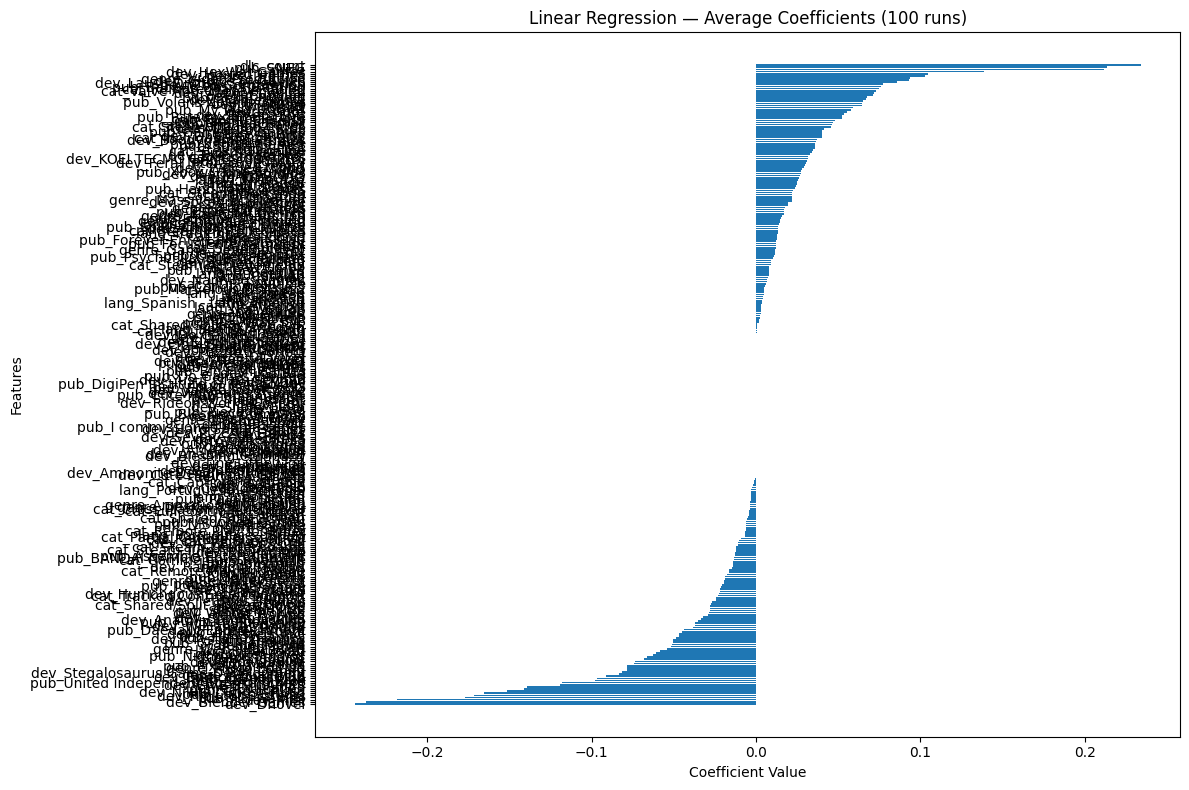

In [24]:
# Average coefficients across all 100 runs
fin_lst_lin = [np.mean([coeff_lin[run][i] for run in range(100)]) for i in range(len(X_lin.columns))]

coef_df_lin = pd.DataFrame({"Variables": X_lin.columns, "Weights": fin_lst_lin}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df_lin["Variables"], coef_df_lin["Weights"])
plt.title("Linear Regression — Average Coefficients (100 runs)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## IX. Ridge Regression (L2)

Ridge Regression is a regularized version of Linear Regression that applies an **L2 penalty**
to the model coefficients. This shrinks all coefficients toward — but not to — zero, improving
stability when features are correlated.

Multiple alpha values are tested and each is evaluated over 100 random train-test splits to find
the best regularization strength.

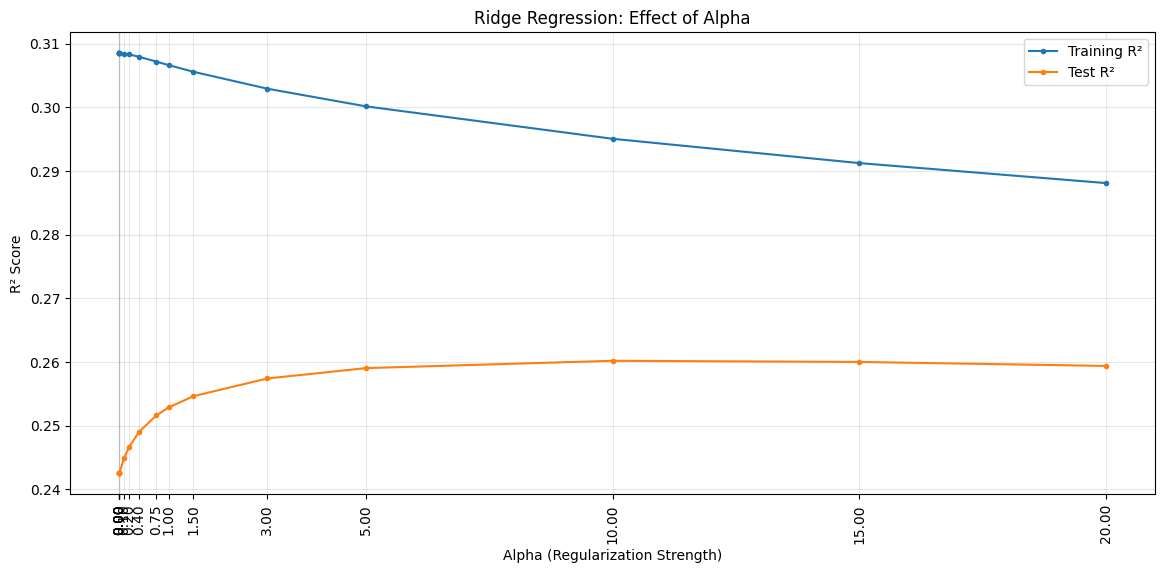

Best alpha: 10
Best average test R²: 0.2602


In [25]:
alpha_ridge = [1e-12, 1e-10, 1e-8, 1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20]

fin_train_ridge = []
fin_test_ridge = []

for alpha in alpha_ridge:
    tr_acc, te_acc = [], []
    for rs in range(0, 100):
        X_tr, X_te, y_tr, y_te = train_test_split(X_lin, y_lin, test_size=0.25, random_state=rs)
        clf = Ridge(alpha=alpha).fit(X_tr, y_tr)
        tr_acc.append(clf.score(X_tr, y_tr))
        te_acc.append(clf.score(X_te, y_te))
    fin_train_ridge.append(np.mean(tr_acc))
    fin_test_ridge.append(np.mean(te_acc))

plt.figure(figsize=(14, 6))
plt.plot(alpha_ridge, fin_train_ridge, label="Training R²", marker='.')
plt.plot(alpha_ridge, fin_test_ridge, label="Test R²", marker='.')
plt.ylabel("R² Score")
plt.xlabel("Alpha (Regularization Strength)")
plt.xticks(alpha_ridge, rotation=90)
plt.title("Ridge Regression: Effect of Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_alpha_ridge = alpha_ridge[np.argmax(fin_test_ridge)]
best_ridge_test = max(fin_test_ridge)
print(f"Best alpha: {best_alpha_ridge}")
print(f"Best average test R²: {best_ridge_test:.4f}")

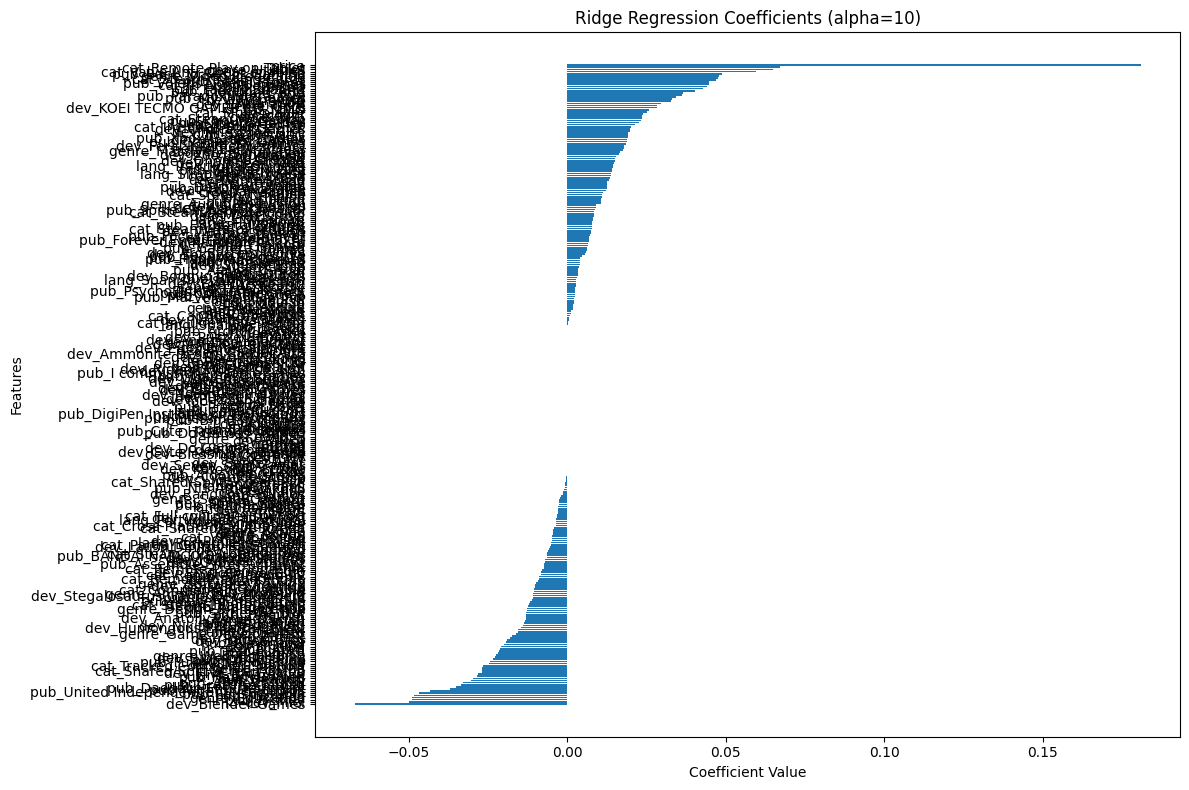

In [26]:
# Retrain best Ridge model and plot coefficients
coeff_ridge = []
for rs in range(0, 100):
    X_tr, X_te, y_tr, y_te = train_test_split(X_lin, y_lin, random_state=rs)
    ridge_best = Ridge(alpha=best_alpha_ridge)
    ridge_best.fit(X_tr, y_tr)
    coeff_ridge.append(ridge_best.coef_)

fin_lst_ridge = [np.mean([coeff_ridge[run][i] for run in range(100)]) for i in range(len(X_lin.columns))]

coef_df_ridge = pd.DataFrame({"Variables": X_lin.columns, "Weights": fin_lst_ridge}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df_ridge["Variables"], coef_df_ridge["Weights"])
plt.title(f"Ridge Regression Coefficients (alpha={best_alpha_ridge})")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Ridge's regularization at the chosen alpha spreads influence across many features rather than
concentrating it. This is consistent with the dataset: playtime is driven by a combination of many
small signals rather than one or two dominant predictors. Coefficient magnitudes are tightly clustered
around zero, with only a handful of features standing out.

## X. Lasso Regression (L1)

Lasso Regression applies an **L1 penalty**, which has the key property of shrinking some coefficients
*exactly* to zero. This performs automatic feature selection — a useful property for high-dimensional
sparse datasets like this one.

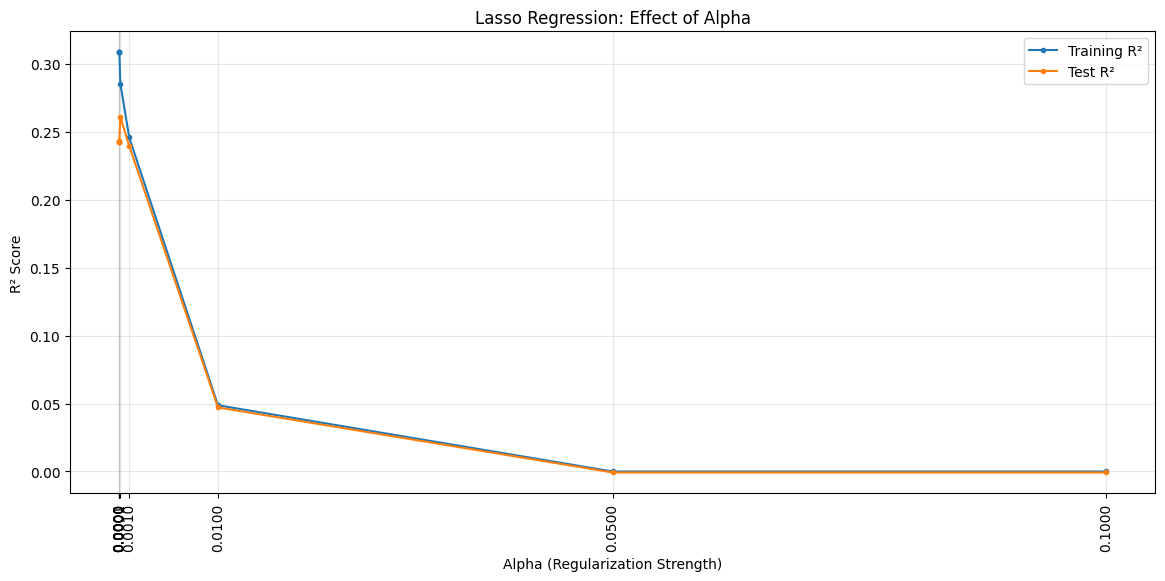

Best alpha: 0.0001
Best average test R²: 0.2611


In [27]:
alpha_lasso = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 0.05, 0.1]

fin_train_lasso = []
fin_test_lasso = []

for alpha in alpha_lasso:
    tr_acc, te_acc = [], []
    for rs in range(0, 100):
        X_tr, X_te, y_tr, y_te = train_test_split(X_lin, y_lin, test_size=0.25, random_state=rs)
        clf = Lasso(alpha=alpha, max_iter=100000).fit(X_tr, y_tr)
        tr_acc.append(clf.score(X_tr, y_tr))
        te_acc.append(clf.score(X_te, y_te))
    fin_train_lasso.append(np.mean(tr_acc))
    fin_test_lasso.append(np.mean(te_acc))

plt.figure(figsize=(14, 6))
plt.plot(alpha_lasso, fin_train_lasso, label="Training R²", marker='.')
plt.plot(alpha_lasso, fin_test_lasso, label="Test R²", marker='.')
plt.ylabel("R² Score")
plt.xlabel("Alpha (Regularization Strength)")
plt.xticks(alpha_lasso, rotation=90)
plt.title("Lasso Regression: Effect of Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_alpha_lasso = alpha_lasso[np.argmax(fin_test_lasso)]
best_lasso_test = max(fin_test_lasso)
print(f"Best alpha: {best_alpha_lasso}")
print(f"Best average test R²: {best_lasso_test:.4f}")

Features used (non-zero coef): 98 out of 302


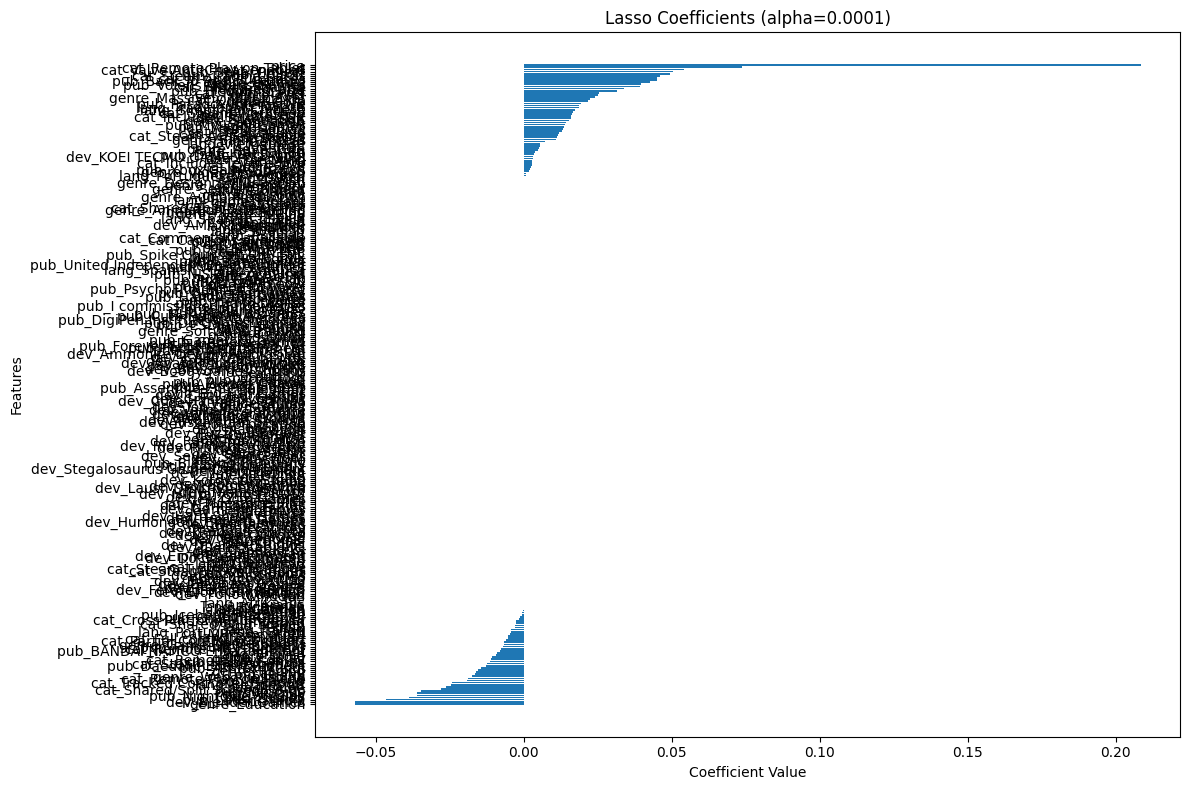

In [28]:
# Train best Lasso model on a representative split
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_lin, y_lin, test_size=0.25, random_state=42)
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=100000)
lasso_best.fit(X_tr_f, y_tr_f)

print(f"Features used (non-zero coef): {np.sum(lasso_best.coef_ != 0)} out of {X_lin.shape[1]}")

coef_df_lasso = pd.DataFrame({"Variables": X_lin.columns, "Weights": lasso_best.coef_}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df_lasso["Variables"], coef_df_lasso["Weights"])
plt.title(f"Lasso Coefficients (alpha={best_alpha_lasso})")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

---
## XI. Logistic Regression and SVM Classification

Logistic Regression uses the sigmoid function to output the probability of a binary outcome.
`LinearSVC` finds the optimal margin-maximizing hyperplane between classes.

Both models are tested with **L1** and **L2** regularization, sweeping the `C` hyperparameter
(smaller C = stronger regularization, the inverse of alpha in regression terms).

These models are trained on `X_train_cls` / `y_train_cls` — the original (non-SMOTE) split.

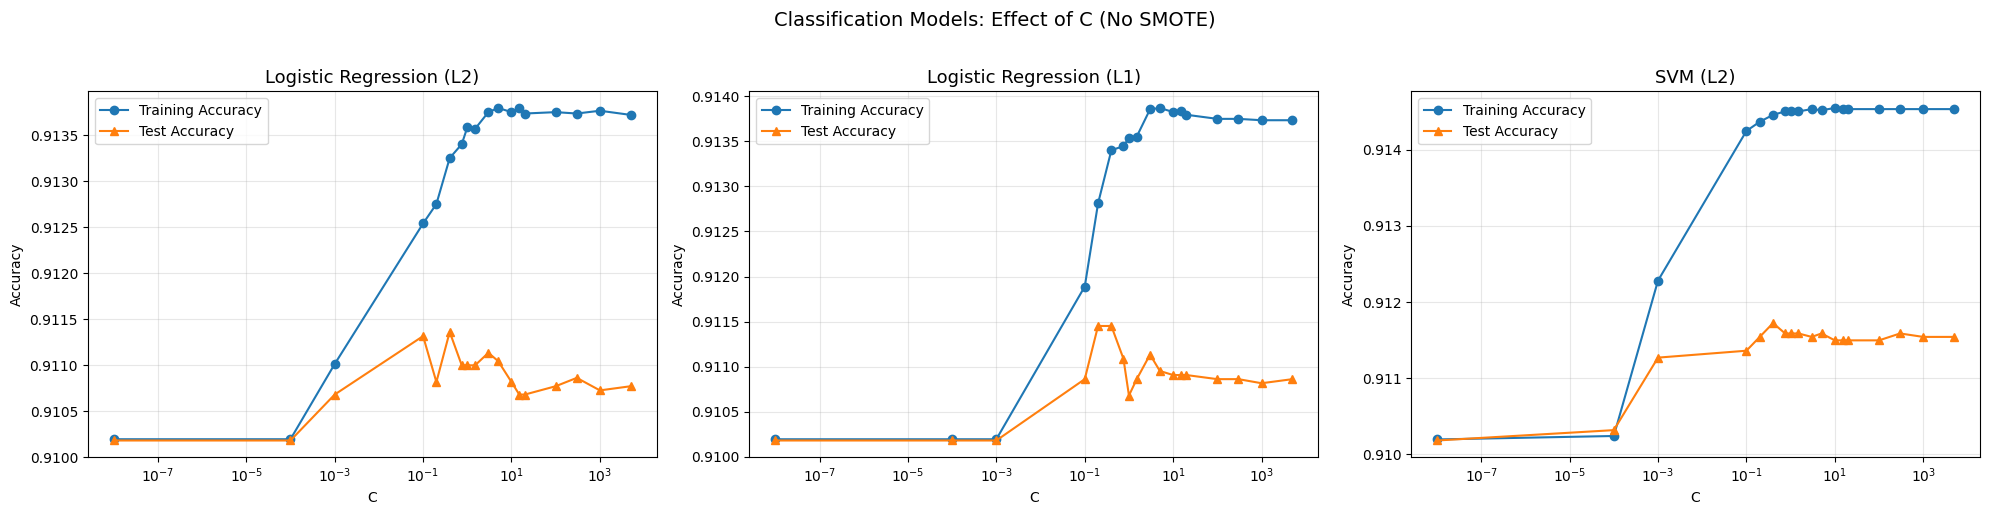

Best C — LR (L2): 0.4  |  LR (L1): 0.2  |  SVM (L2): 0.4


In [29]:
C_values = [1e-8, 1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 5000]

# ── Logistic Regression L2 ──────────────────────────────────────────────────
tr_l2, te_l2 = [], []
for C in C_values:
    lr = LogisticRegression(C=C, solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train_cls, y_train_cls)
    tr_l2.append(lr.score(X_train_cls, y_train_cls))
    te_l2.append(lr.score(X_test_cls, y_test_cls))

# ── Logistic Regression L1 ──────────────────────────────────────────────────
tr_l1, te_l1 = [], []
for C in C_values:
    lr = LogisticRegression(C=C, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train_cls, y_train_cls)
    tr_l1.append(lr.score(X_train_cls, y_train_cls))
    te_l1.append(lr.score(X_test_cls, y_test_cls))

# ── SVM L2 ──────────────────────────────────────────────────────────────────
tr_svm_l2, te_svm_l2 = [], []
for C in C_values:
    svm = LinearSVC(C=C, penalty="l2", loss='squared_hinge', dual=False, random_state=42, max_iter=2000)
    svm.fit(X_train_cls, y_train_cls)
    tr_svm_l2.append(svm.score(X_train_cls, y_train_cls))
    te_svm_l2.append(svm.score(X_test_cls, y_test_cls))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, tr, te, title in zip(
    axes,
    [tr_l2, tr_l1, tr_svm_l2],
    [te_l2, te_l1, te_svm_l2],
    ["Logistic Regression (L2)", "Logistic Regression (L1)", "SVM (L2)"]
):
    ax.set_xscale('log')
    ax.plot(C_values, tr, marker='o', label='Training Accuracy')
    ax.plot(C_values, te, marker='^', label='Test Accuracy')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('C')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Classification Models: Effect of C (No SMOTE)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

best_C_l2  = C_values[np.argmax(te_l2)]
best_C_l1  = C_values[np.argmax(te_l1)]
best_C_svm = C_values[np.argmax(te_svm_l2)]
print(f"Best C — LR (L2): {best_C_l2}  |  LR (L1): {best_C_l1}  |  SVM (L2): {best_C_svm}")

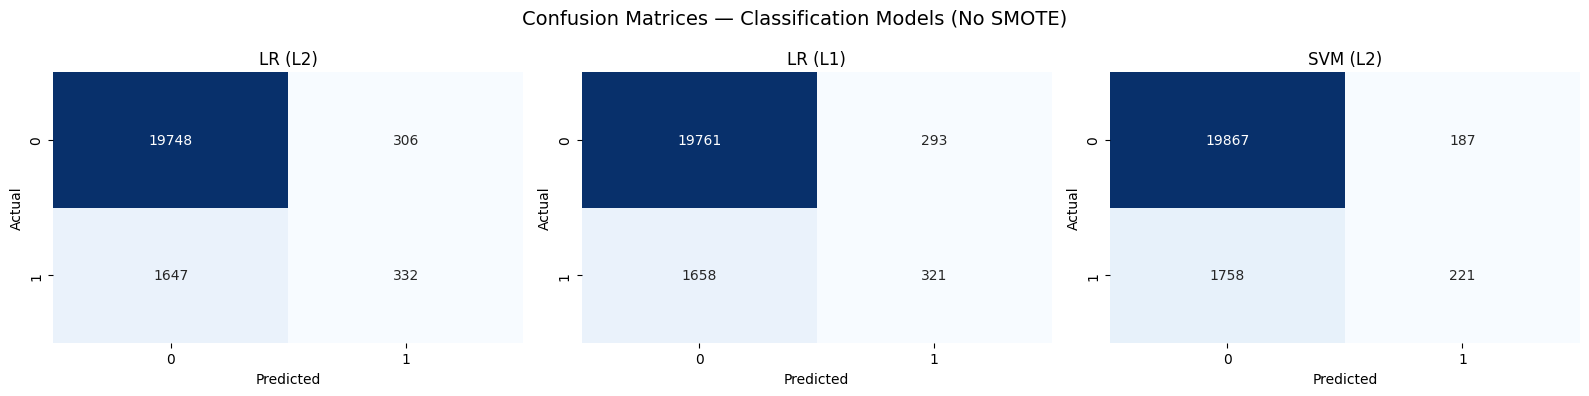

In [30]:
# Train final classification models
lr_l2_best  = LogisticRegression(C=best_C_l2, solver='liblinear', random_state=42, max_iter=1000)
lr_l1_best  = LogisticRegression(C=best_C_l1, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
svm_l2_best = LinearSVC(C=best_C_svm, penalty="l2", loss='squared_hinge', dual=False, random_state=42, max_iter=2000)

lr_l2_best.fit(X_train_cls, y_train_cls)
lr_l1_best.fit(X_train_cls, y_train_cls)
svm_l2_best.fit(X_train_cls, y_train_cls)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, (name, model) in enumerate([
    ("LR (L2)", lr_l2_best), ("LR (L1)", lr_l1_best), ("SVM (L2)", svm_l2_best)
]):
    cm = confusion_matrix(y_test_cls, model.predict(X_test_cls))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name}", fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle("Confusion Matrices — Classification Models (No SMOTE)", fontsize=14)
plt.tight_layout()
plt.show()

## XII. Logistic Regression with SMOTE

### The Class Imbalance Problem

When games are split at the median playtime, the resulting binary classes may still be imbalanced
due to how the data is distributed. A model trained on imbalanced data tends to favor the majority
class — reporting high accuracy while doing poorly on the minority class.

**SMOTE** (Synthetic Minority Over-sampling Technique) addresses this by interpolating new
synthetic samples for the minority class in feature space, rather than simply duplicating existing ones.

> SMOTE is applied **only to the training set**. The test set remains untouched to give an unbiased evaluation.

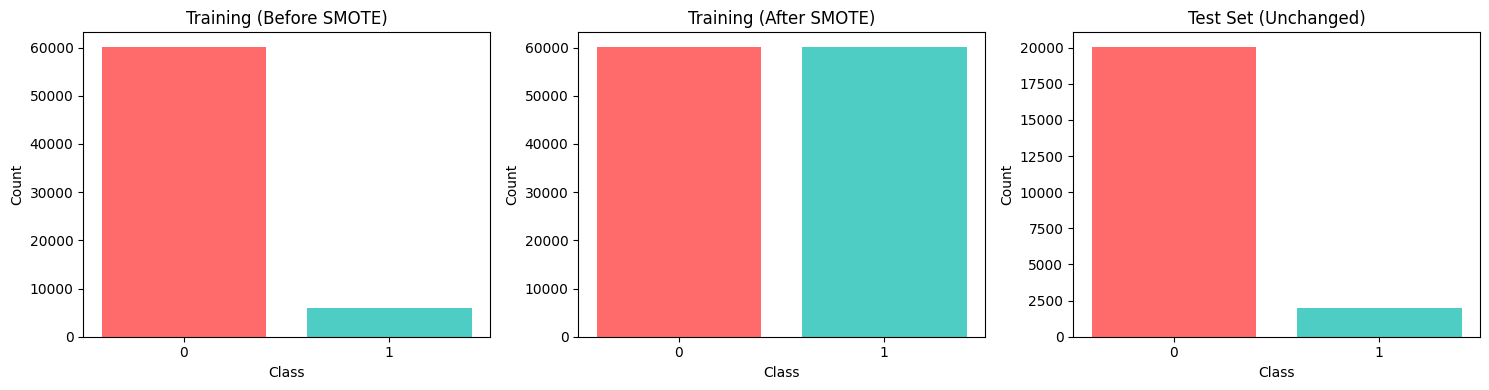

In [31]:
# Visualize SMOTE effect
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, counts, title in zip(
    axes,
    [Counter(y_train_cls), Counter(y_train_smote), Counter(y_test_cls)],
    ["Training (Before SMOTE)", "Training (After SMOTE)", "Test Set (Unchanged)"]
):
    ax.bar(counts.keys(), counts.values(), color=['#FF6B6B', '#4ECDC4'])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1])

plt.tight_layout()
plt.show()

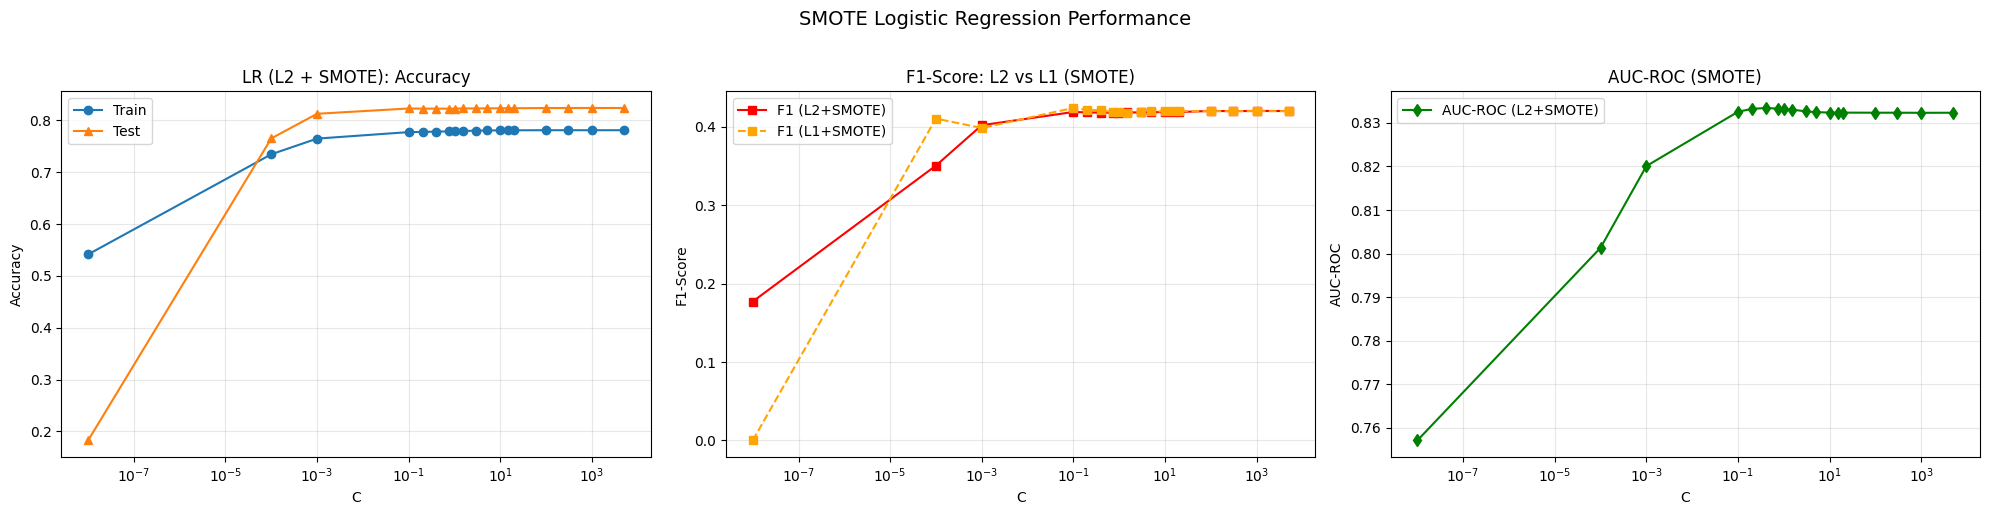

Best C (L2+SMOTE by F1): 1000  |  Best C (L1+SMOTE by F1): 0.1


In [32]:
# Train SMOTE models across C range
tr_l2_sm, te_l2_sm, f1_l2_sm, auc_l2_sm = [], [], [], []
tr_l1_sm, te_l1_sm, f1_l1_sm = [], [], []

for C in C_values:
    # L2 + SMOTE
    lr = LogisticRegression(C=C, solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train_smote, y_train_smote)
    tr_l2_sm.append(lr.score(X_train_smote, y_train_smote))
    te_l2_sm.append(lr.score(X_test_cls, y_test_cls))
    yp = lr.predict(X_test_cls)
    f1_l2_sm.append(f1_score(y_test_cls, yp))
    auc_l2_sm.append(roc_auc_score(y_test_cls, lr.predict_proba(X_test_cls)[:, 1]))

    # L1 + SMOTE
    lr1 = LogisticRegression(C=C, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
    lr1.fit(X_train_smote, y_train_smote)
    tr_l1_sm.append(lr1.score(X_train_smote, y_train_smote))
    te_l1_sm.append(lr1.score(X_test_cls, y_test_cls))
    f1_l1_sm.append(f1_score(y_test_cls, lr1.predict(X_test_cls)))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].set_xscale('log')
axes[0].plot(C_values, tr_l2_sm, marker='o', label='Train')
axes[0].plot(C_values, te_l2_sm, marker='^', label='Test')
axes[0].set_title("LR (L2 + SMOTE): Accuracy")
axes[0].set_xlabel('C'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xscale('log')
axes[1].plot(C_values, f1_l2_sm, marker='s', label='F1 (L2+SMOTE)', color='red')
axes[1].plot(C_values, f1_l1_sm, marker='s', label='F1 (L1+SMOTE)', color='orange', linestyle='--')
axes[1].set_title("F1-Score: L2 vs L1 (SMOTE)")
axes[1].set_xlabel('C'); axes[1].set_ylabel('F1-Score')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].set_xscale('log')
axes[2].plot(C_values, auc_l2_sm, marker='d', label='AUC-ROC (L2+SMOTE)', color='green')
axes[2].set_title("AUC-ROC (SMOTE)")
axes[2].set_xlabel('C'); axes[2].set_ylabel('AUC-ROC')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("SMOTE Logistic Regression Performance", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

best_C_l2_sm = C_values[np.argmax(f1_l2_sm)]
best_C_l1_sm = C_values[np.argmax(f1_l1_sm)]
print(f"Best C (L2+SMOTE by F1): {best_C_l2_sm}  |  Best C (L1+SMOTE by F1): {best_C_l1_sm}")

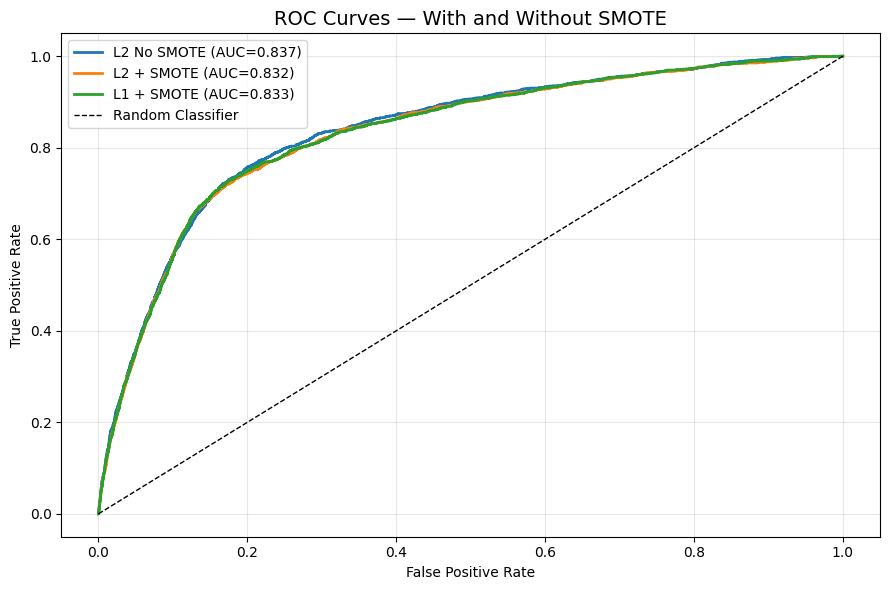

In [33]:
# Train and compare SMOTE models
lr_l2_smote = LogisticRegression(C=best_C_l2_sm, solver='liblinear', random_state=42, max_iter=1000)
lr_l1_smote = LogisticRegression(C=best_C_l1_sm, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
lr_l2_smote.fit(X_train_smote, y_train_smote)
lr_l1_smote.fit(X_train_smote, y_train_smote)

# ROC curves
plt.figure(figsize=(9, 6))
for name, model in [("L2 No SMOTE", lr_l2_best), ("L2 + SMOTE", lr_l2_smote), ("L1 + SMOTE", lr_l1_smote)]:
    yp = model.predict_proba(X_test_cls)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_cls, yp)
    auc = roc_auc_score(y_test_cls, yp)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — With and Without SMOTE', fontsize=14)
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## XIII. Cross-Model Comparison and Results

### 13.1 — Regression Models (R² Score)

In [34]:
# Regression comparison
lin_top3 = pd.DataFrame({"Variables": X_lin.columns, "Weights": fin_lst_lin})
lin_top3["Abs"] = lin_top3["Weights"].abs()
lin_top3 = lin_top3.sort_values("Abs", ascending=False)

ridge_top3 = pd.DataFrame({"Variables": X_lin.columns, "Weights": fin_lst_ridge})
ridge_top3["Abs"] = ridge_top3["Weights"].abs()
ridge_top3 = ridge_top3.sort_values("Abs", ascending=False)

lasso_top3 = pd.DataFrame({"Variables": X_lin.columns, "Weights": lasso_best.coef_})
lasso_top3["Abs"] = lasso_top3["Weights"].abs()
lasso_top3 = lasso_top3.sort_values("Abs", ascending=False)

regression_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "Avg Train R²": [
        f"{np.mean(training_accuracy_lin):.4f}",
        f"{fin_train_ridge[np.argmax(fin_test_ridge)]:.4f}",
        f"{fin_train_lasso[np.argmax(fin_test_lasso)]:.4f}"
    ],
    "Avg Test R²": [
        f"{np.mean(test_accuracy_lin):.4f}",
        f"{best_ridge_test:.4f}",
        f"{best_lasso_test:.4f}"
    ],
    "Best Hyperparameter": ["N/A", str(best_alpha_ridge), str(best_alpha_lasso)],
    "Top 3 Features": [
        ", ".join(lin_top3["Variables"].head(3).values),
        ", ".join(ridge_top3["Variables"].head(3).values),
        ", ".join(lasso_top3["Variables"].head(3).values)
    ]
})

print("Regression Models — Performance Summary")
regression_comparison

Regression Models — Performance Summary


,Model,Avg Train R²,Avg Test R²,Best Hyperparameter,Top 3 Features
0,Linear Regression,0.3085,0.2425,N/A,"dev_Dnovel, dev_Blender Games, dlc_count"
1,Ridge Regression,0.2951,0.2602,10,"price, dev_Blender Games, cat_Remote Play on T..."
2,Lasso Regression,0.2857,0.2611,0.0001,"price, cat_Remote Play on Tablet, genre_Education"


### 13.2 — Classification Models (Accuracy, F1, AUC-ROC)

In [35]:
# Classification comparison
cls_models = {
    "LR (L2, No SMOTE)": lr_l2_best,
    "LR (L1, No SMOTE)": lr_l1_best,
    "SVM (L2, No SMOTE)": svm_l2_best,
    "LR (L2 + SMOTE)": lr_l2_smote,
    "LR (L1 + SMOTE)": lr_l1_smote,
}

cls_results = []
for name, model in cls_models.items():
    yp = model.predict(X_test_cls)
    try:
        yp_prob = model.predict_proba(X_test_cls)[:, 1]
        auc = f"{roc_auc_score(y_test_cls, yp_prob):.4f}"
    except AttributeError:
        auc = "N/A (no predict_proba)"

    cls_results.append({
        "Model": name,
        "Test Accuracy": f"{accuracy_score(y_test_cls, yp):.4f}",
        "Precision": f"{precision_score(y_test_cls, yp):.4f}",
        "Recall": f"{recall_score(y_test_cls, yp):.4f}",
        "F1-Score": f"{f1_score(y_test_cls, yp):.4f}",
        "AUC-ROC": auc,
    })

cls_df = pd.DataFrame(cls_results)
print("Classification Models — Performance Summary")
cls_df

Classification Models — Performance Summary


,Model,Test Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,"LR (L2, No SMOTE)",0.9114,0.5204,0.1678,0.2537,0.8369
1,"LR (L1, No SMOTE)",0.9115,0.5228,0.1622,0.2476,0.8323
2,"SVM (L2, No SMOTE)",0.9117,0.5417,0.1117,0.1852,N/A (no predict_proba)
3,LR (L2 + SMOTE),0.8239,0.2983,0.7105,0.4202,0.8323
4,LR (L1 + SMOTE),0.8264,0.3020,0.7115,0.4240,0.8328


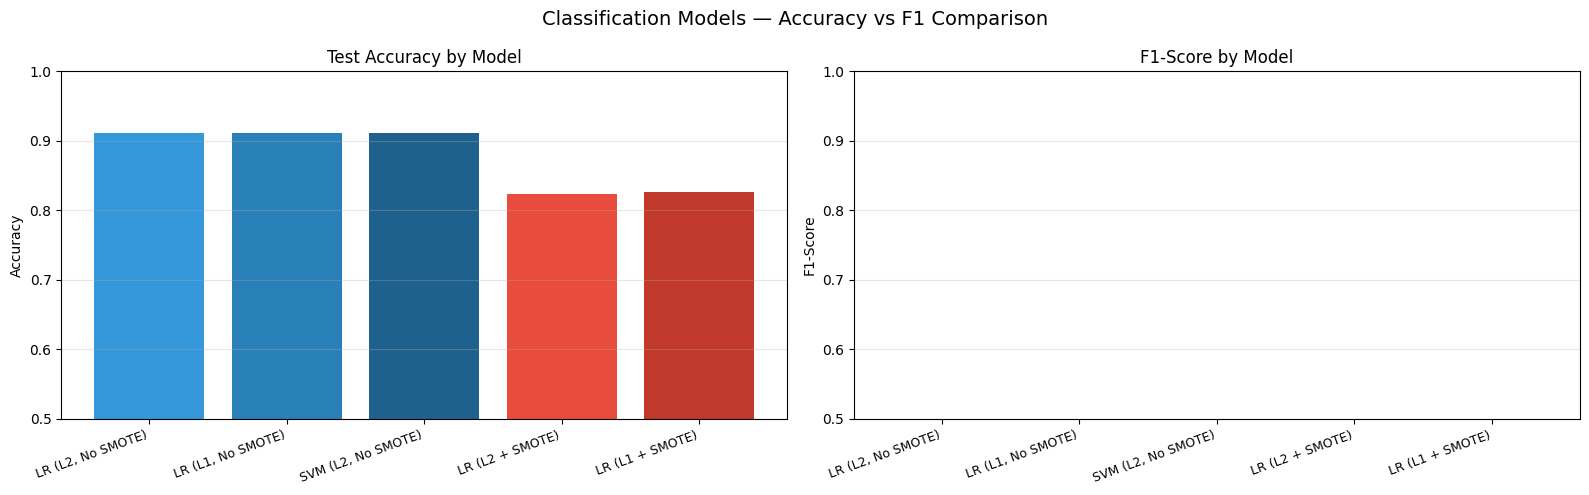

In [36]:
# Visual comparison of classification models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

model_names = [r["Model"] for r in cls_results]
f1_scores   = [float(r["F1-Score"]) for r in cls_results]
accuracies  = [float(r["Test Accuracy"]) for r in cls_results]
x = np.arange(len(model_names))

axes[0].bar(x, accuracies, color=['#3498db','#2980b9','#1f618d','#e74c3c','#c0392b'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[0].set_title("Test Accuracy by Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, f1_scores, color=['#3498db','#2980b9','#1f618d','#e74c3c','#c0392b'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[1].set_title("F1-Score by Model")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Classification Models — Accuracy vs F1 Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## XIV. Top Features Across All Models

In [37]:
# Feature importance: top 3 per regression model
print("=== Regression: Top 3 Features by Absolute Coefficient ===\n")
for name, df_top in [("Linear", lin_top3), ("Ridge", ridge_top3), ("Lasso", lasso_top3)]:
    top = df_top.head(3)
    print(f"{name} Regression:")
    for _, row in top.iterrows():
        print(f"  {row['Variables']:35s}  coef = {row['Weights']:+.4f}")
    print()

=== Regression: Top 3 Features by Absolute Coefficient ===

Linear Regression:
  dev_Dnovel                           coef = -0.2443
  dev_Blender Games                    coef = -0.2376
  dlc_count                            coef = +0.2340

Ridge Regression:
  price                                coef = +0.1808
  dev_Blender Games                    coef = -0.0670
  cat_Remote Play on Tablet            coef = +0.0670

Lasso Regression:
  price                                coef = +0.2084
  cat_Remote Play on Tablet            coef = +0.0737
  genre_Education                      coef = -0.0572



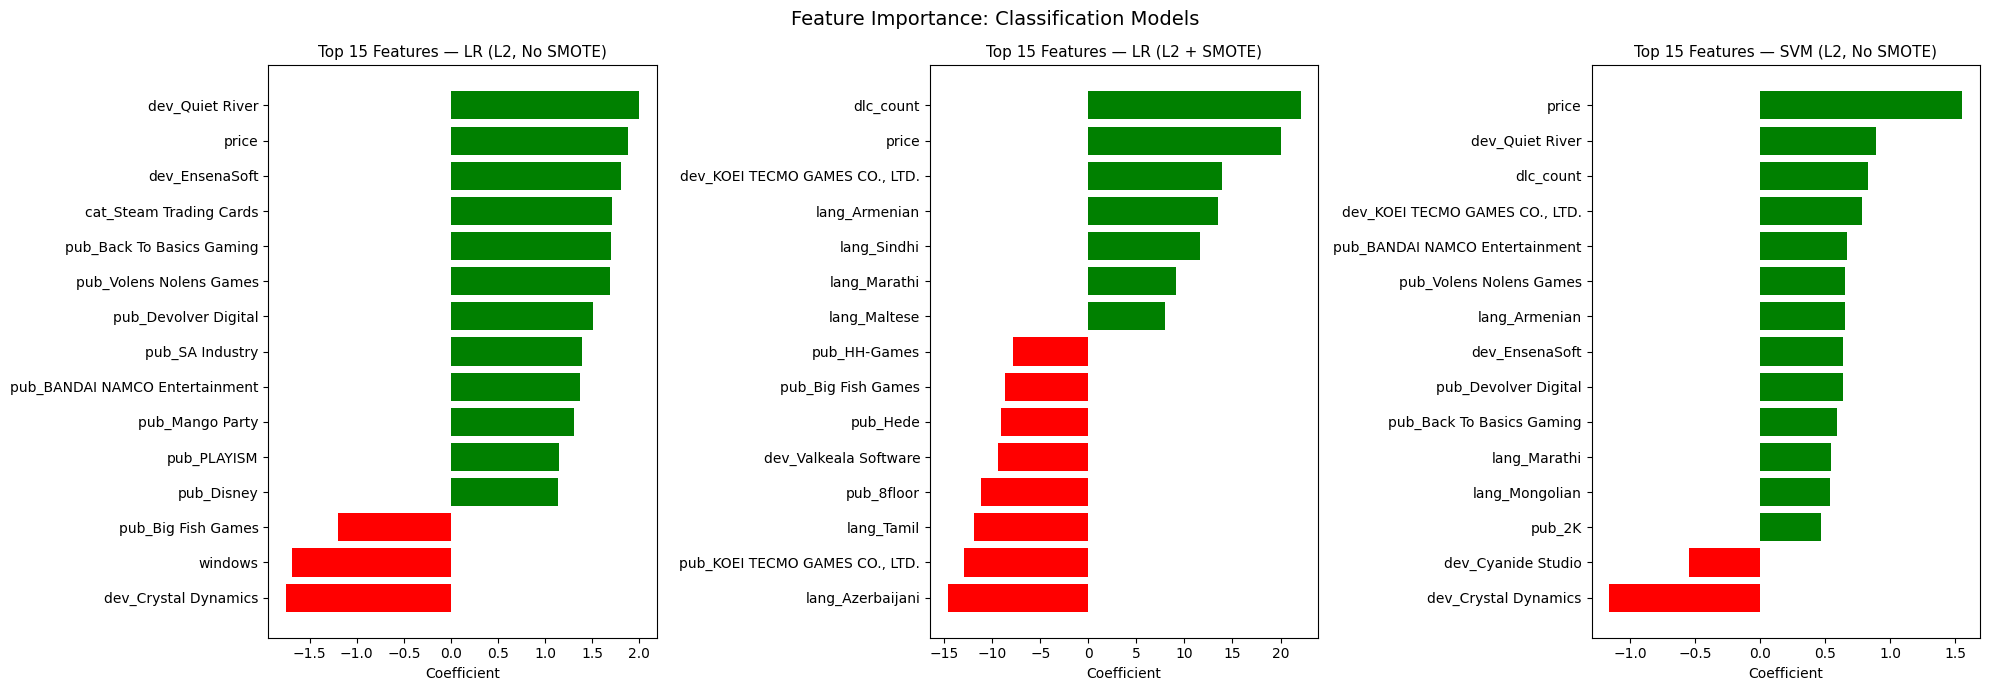

In [38]:
# Feature importance: top 10 from classification models
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (name, model) in zip(axes, [
    ("LR (L2, No SMOTE)", lr_l2_best),
    ("LR (L2 + SMOTE)", lr_l2_smote),
    ("SVM (L2, No SMOTE)", svm_l2_best)
]):
    coef = model.coef_[0]
    fi = pd.DataFrame({"Feature": X_cls_norm.columns, "Coefficient": coef})
    fi["Abs"] = fi["Coefficient"].abs()
    fi = fi.nlargest(15, "Abs").sort_values("Coefficient")
    colors = ['red' if x < 0 else 'green' for x in fi['Coefficient']]
    ax.barh(fi['Feature'], fi['Coefficient'], color=colors)
    ax.set_title(f"Top 15 Features — {name}", fontsize=11)
    ax.set_xlabel("Coefficient")

plt.suptitle("Feature Importance: Classification Models", fontsize=14)
plt.tight_layout()
plt.show()

---
## XV. Why Are the Results So Different? — Interpretation

The three notebooks achieve very different reported scores, and understanding why is as important
as the scores themselves.

### 1. Problem Framing: Regression vs. Classification

The most fundamental difference is in how the target variable `average_playtime_forever` is treated:

- **Regression** keeps it as a continuous value (after log-transformation) and measures
  **R²** — the proportion of variance explained. R² of 0.29–0.34 means the model captures
  roughly 30% of the variance in playtime. This is a genuinely hard prediction task.
- **Classification** binarizes the same variable at the median into a 50/50 split, then reports
  **accuracy**. On a balanced binary problem a random classifier already achieves ~50%, and even
  a weak model can push well above that.

These metrics are not comparable. An accuracy of 65% in classification does not mean
the model is "better" than an R² of 0.34 in regression — they are measuring different things.

### 2. Target Transformation and Information Loss

By converting `average_playtime_forever` into a binary label, the classification notebooks discard
the magnitude information. Two games with 100 and 100,000 hours of playtime receive the same label
(both above median). This simplification makes the task easier but less informative.

The regression notebook additionally applies `log1p` to the target, which reduces right-skew
and makes the linear model's assumptions more appropriate. The classification notebooks do not
need this step since the label is already categorical.

### 3. Class Imbalance and the Role of SMOTE

The median-split binarization in the classification notebooks produces a nominally balanced dataset
(~50/50 by construction), but the underlying distribution of engagement is right-skewed — most games
have very low playtime. SMOTE addresses any residual imbalance and, more importantly, its effect
is most visible in **F1-score and recall** rather than accuracy. When SMOTE improves F1 noticeably
without improving accuracy much, it means the original model was predicting the majority class too often.

### 4. Regularization: C vs. Alpha

Both regression and classification models use regularization, but the parameterization is inverted:
- In **Ridge/Lasso**, `alpha` directly scales the penalty — *larger alpha* means *stronger regularization*.
- In **Logistic Regression/SVM**, `C` is the inverse: *smaller C* means *stronger regularization*.

This is a common source of confusion when comparing notebooks side by side.

### 5. Feature Consistency

All models consistently identify **price** as one of the most influential features. Across Ridge,
Lasso, and the classification models, price carries the largest absolute coefficient. Higher-priced
games tend to attract more committed players, translating into longer playtime. Genre and developer
identity are the next most consistent signals.

### Summary Table

| Factor | Linear/Ridge/Lasso | Logistic/SVM | Logistic + SMOTE |
|---|---|---|---|
| Target | Continuous (log R²) | Binary (accuracy) | Binary (F1, AUC) |
| Metric | R² ≈ 0.26–0.34 | Accuracy ≈ 60–70% | F1 / AUC-ROC |
| Regularization param | Alpha (larger = stronger) | C (smaller = stronger) | C (same as Logistic/SVM) |
| Handles imbalance? | N/A (regression) | No | Yes (SMOTE) |
| Feature selection | Lasso (L1) eliminates features | L1 shrinks to zero | L1 + SMOTE |
| Top feature | price | price / playtime-related | price / playtime-related |


## XVI. Conclusion

This unified analysis demonstrates that predicting player engagement from Steam game metadata is
a genuinely challenging task, regardless of how the problem is framed.

**Regression** (Linear, Ridge, Lasso) shows that roughly 30% of the variance in average playtime
can be explained by structured game attributes — price, genre, developer identity, and platform support.
The remaining 70% is driven by factors not in the dataset: social trends, influencer coverage, and the
inherently stochastic nature of what makes a game "sticky."

**Classification** (Logistic Regression, SVM) reframes the same problem as a binary question and
achieves accuracy in the 60–70% range, consistently better than chance. The addition of SMOTE improves
recall for the minority class and raises F1-score, showing the value of addressing class imbalance
even when the split appears roughly balanced.

Across all approaches, **price** emerges as the single most reliable predictor of engagement — higher-
priced games consistently attract more committed players. Genre and top developer identity are the next
most useful signals.

The close alignment between training and test performance across all models confirms that the pipeline
of data cleaning, categorical encoding, log-transformation, and regularization produces stable and
generalizable models. The choice of which approach to use depends on the downstream question:
if you need a ranking or a magnitude estimate, use regression; if you need a binary decision rule, use
the classification approach with SMOTE for fairer minority-class recall.